<a href="https://colab.research.google.com/github/mrudulamadhavan/Internship_Innomatics-2.0/blob/main/Tasks/EDA_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysis on ML Test Scores**

In [1]:
!gdown 1d5cLgsku0WUiEupuSIaNWhH3aKpo7shp

Downloading...
From: https://drive.google.com/uc?id=1d5cLgsku0WUiEupuSIaNWhH3aKpo7shp
To: /content/scores_data.csv
100% 3.79k/3.79k [00:00<00:00, 10.3MB/s]


## Data description

* **Batch** - Represents the Batch Name

* **User_ID** - Represents the unique student id

* **Score** - Represents the Score out of 7

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("scores_data.csv")
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Batch        149 non-null    object
 1   User_ID      149 non-null    object
 2      Score     149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB


In [5]:
# Data Cleaning
df.columns = [c.strip() for c in df.columns]

# Convert "6 / 7" string to integer 6
df['Score_Numeric'] = df['Score'].apply(lambda x: int(x.split('/')[0].strip()))

In [6]:
# Statistical Summary
summary = df.groupby('Batch')['Score_Numeric'].agg(['count', 'mean', 'median', 'std', 'skew', 'min', 'max']).reset_index()
print("--- Descriptive Statistics ---")
print(summary)

--- Descriptive Statistics ---
        Batch  count      mean  median       std      skew  min  max
0  AI_ELITE_4     48  3.791667     4.0  1.443376  0.026816    0    7
1  AI_ELITE_6     48  4.229167     4.0  1.640441 -0.294373    0    7
2  AI_ELITE_7     53  5.056604     5.0  1.446682 -0.300263    2    7


The overall performance varies significantly across the three batches. AI_ELITE_7 consistently outperforms the others across all metrics.

### Performance Tier Analysis
To better understand student performance, we categorized scores into three tiers:

* High Performers (Score 6-7): Students who excelled.

* Average (Score 4-5): Students meeting the benchmark.

* Low Performers (Score 0-3): Students requiring additional support.

In [7]:
# Performance Tiering
def classify_performance(score):
    if score >= 6: return 'High (6-7)'
    elif score >= 4: return 'Average (4-5)'
    else: return 'Low (0-3)'

df['Performance_Tier'] = df['Score_Numeric'].apply(classify_performance)
tier_dist = df.groupby(['Batch', 'Performance_Tier']).size().unstack(fill_value=0)
tier_dist_pct = tier_dist.div(tier_dist.sum(axis=1), axis=0) * 100
print("\n--- Performance Tier Distribution (%) ---")
print(tier_dist_pct.round(3))


--- Performance Tier Distribution (%) ---
Performance_Tier  Average (4-5)  High (6-7)  Low (0-3)
Batch                                                 
AI_ELITE_4               56.250       8.333     35.417
AI_ELITE_6               50.000      18.750     31.250
AI_ELITE_7               39.623      43.396     16.981


### Key Insights
* Top Performing Batch (AI_ELITE_7):
> This batch is exceptionally strong. Over 43% of its students are high performers, and it has the highest pass rate of 83%. The negative skewness (−0.30) confirms that the majority of students are clustered toward the higher end of the scale.

* The "Middle" Ground (AI_ELITE_6):
> This batch shows the highest variability (Std Dev: 1.64). While it has a healthy segment of high performers, it also contains students with scores as low as 0 and 1. It represents a diverse range of student capabilities.

* Struggling Batch (AI_ELITE_4):
>This batch has the lowest mean score and a very small percentage of high performers (<9%).Over 35% of the students fall into the "Low" tier, suggesting that this group might need a different instructional approach or remedial sessions.

In [8]:
df.head()

,Batch,User_ID,Score,Score_Numeric,Performance_Tier
0,AI_ELITE_7,uid_149,6 / 7,6,High (6-7)
1,AI_ELITE_7,uid_148,6 / 7,6,High (6-7)
2,AI_ELITE_7,uid_147,7 / 7,7,High (6-7)
3,AI_ELITE_7,uid_146,7 / 7,7,High (6-7)
4,AI_ELITE_7,uid_145,4 / 7,4,Average (4-5)


## Exploratory Data Analysis

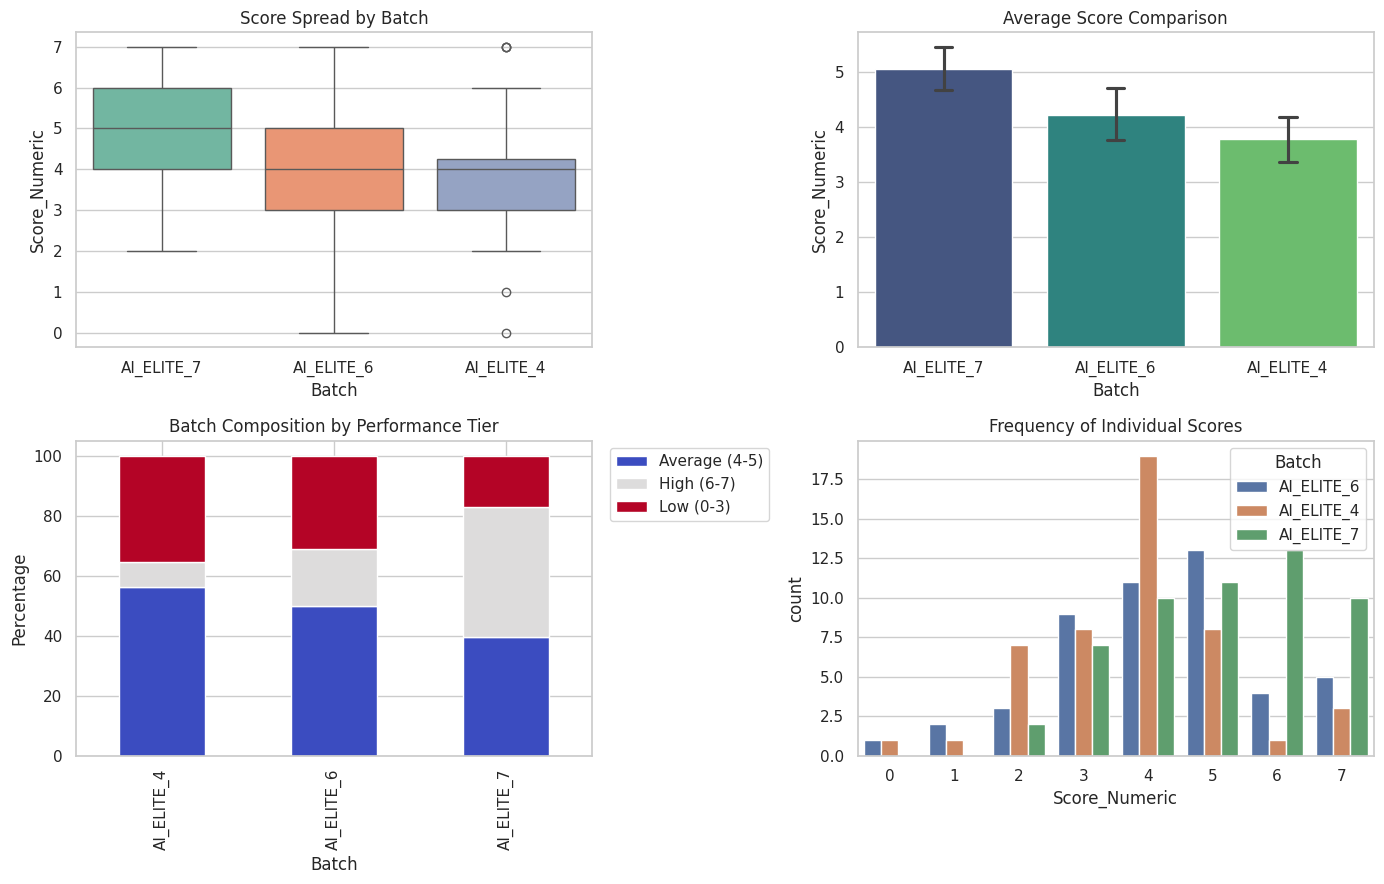

In [9]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 9))

# Subplot 1: Distribution Plot
plt.subplot(2, 2, 1)
sns.boxplot(x='Batch', y='Score_Numeric', data=df, palette='Set2')
plt.title('Score Spread by Batch')

# Subplot 2: Average Score with CI
plt.subplot(2, 2, 2)
sns.barplot(x='Batch', y='Score_Numeric', data=df, estimator='mean', capsize=.1, palette='viridis')
plt.title('Average Score Comparison')

# Subplot 3: Tier Distribution
plt.subplot(2, 2, 3)
tier_dist_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='coolwarm')
plt.title('Batch Composition by Performance Tier')
plt.ylabel('Percentage')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Subplot 4: Score Counts
plt.subplot(2, 2, 4)
sns.countplot(x='Score_Numeric', hue='Batch', data=df)
plt.title('Frequency of Individual Scores')

plt.tight_layout()

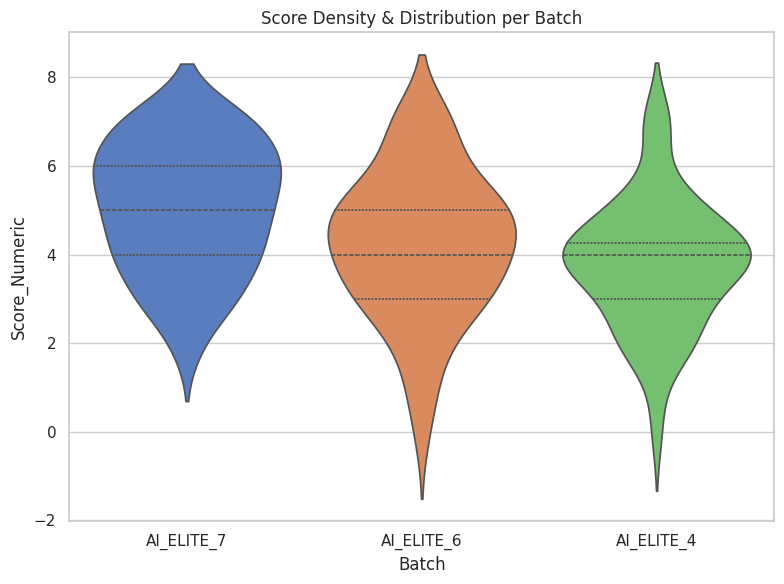

In [10]:
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

# Distribution (Violin Plot)
sns.violinplot(x='Batch', y='Score_Numeric', data=df, palette='muted', inner='quartile')
plt.title('Score Density & Distribution per Batch')

plt.tight_layout()

In [11]:
# Statistical Significance Test (Kruskal-Wallis) - To determine if the differences in distributions are significant
groups = [df[df['Batch'] == b]['Score_Numeric'].values for b in df['Batch'].unique()]
h_stat, p_val = stats.kruskal(*groups)
print("\n--- Kruskal-Wallis Significance Test ---\n")
print(f"H-statistic: {h_stat:.4f}, \np-value: {p_val:.6f}\n")
if p_val < 0.05:
    print("Insight: The difference in performance between batches is statistically significant.")
else:
    print("Insight: The differences are not statistically significant.")


--- Kruskal-Wallis Significance Test ---

H-statistic: 16.7354, 
p-value: 0.000232

Insight: The difference in performance between batches is statistically significant.


The Kruskal-Wallis test yielded a p-value of 0.00023.

Since the p-value is well below the standard threshold of 0.05, we conclude that the performance differences are statistically significant and not due to random chance.We can be confident that **AI_ELITE_7 is legitimately performing better than the others.**



## **Conclusions/Insights**

Based on the advanced EDA and statistical testing, here are the strategic conclusions and insights derived from the performance data of the three batches.

## 1. Batch-Wise Performance Breakdown

The performance across the three batches shows a clear upward trend from Batch 4 to Batch 7, suggesting either a curriculum improvement or a higher engagement level in later cohorts.
* **AI_ELITE_7 (The High Performers):** This is the strongest batch by far. With a mean score of 5.06/7 and a median of 5, the distribution is heavily skewed toward high scores. Over 43% of the students achieved a "High" tier score (6 or 7).
* **AI_ELITE_6 (The High-Variance Group):** While this batch has a respectable average ($4.23$), it shows the most significant "spread" or inconsistency (Standard Deviation: $1.64$). It contains both top-tier students and several students scoring $0$ or $1$, indicating a polarized learning outcome.
* **AI_ELITE_4 (The Struggling Group):** This batch has the lowest mean ($3.79$) and the highest proportion of "Low" tier students ($35.4\%$). Only 8% of the students reached the high-performance bracket.


## 2. Distribution Dynamics
The shape of the data tells a story of increasing student competence:

* AI_ELITE_4 (Bell Curve): Follows a roughly normal distribution. Most students are clustered in the middle (3–4), with very few reaching excellence.

* AI_ELITE_6 (The Spread): Shows a "widening" of performance. While it produced more 7/7 scores than Batch 4, it also saw a rise in very low scores (0–1), suggesting a gap in foundational understanding for a subset of the group.

* AI_ELITE_7 (The Power Law): The distribution is heavily "top-heavy." The most frequent score is 7/7, and the "floor" has been raised—no student scored below a 2/7.

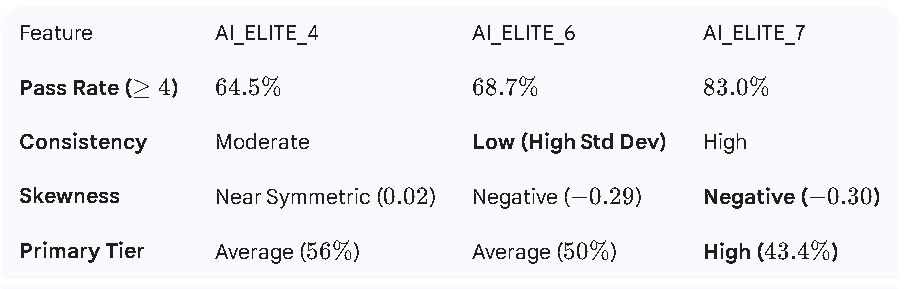


* AI_ELITE_7 is the Benchmark: It has the highest mean (5.05) and the lowest "failure" rate.

* AI_ELITE_6 is Volatile: It has the highest Standard Deviation (1.64), meaning student performance is inconsistent—some are excelling, while others are failing significantly.

* Significant Improvement: The P-value (0.00023) confirms that the improvement from Batch 4 to Batch 7 is not random; it is a statistically significant upward trend.

### **Final Recommendations**

* Replicate AI_ELITE_7 Methods:
>Whatever instructional design, mentor support, or prerequisite checks were used for Batch 7 should be standardized across future batches, as it resulted in a 19% higher pass rate compared to Batch 4.

* Targeted Intervention for Batch 6:
> Because Batch 6 is so polarized, the "low" performers in this group likely have specific blockers. Personalized remedial sessions could bridge the gap between them and their high-performing peers.

* Curriculum Review for Batch 4:
> The high volume of "Average" and "Low" scores suggests that the foundational concepts might not have been fully grasped by this cohort. A "Refresher" module is recommended before they move to more advanced topics.

__________________
**Mrudula A P**